In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dt = '2026-02-06'
ohlcv_1m = pd.read_parquet(f'data/raw/amberdata/market_data/spot/ohlcv_1m/binance/{dt}/eth_usdt.parquet')

In [12]:
def load_data(dt):
    ohlcv_1m = pd.read_parquet(f'data/raw/amberdata/market_data/spot/ohlcv_1m/binance/{dt}/eth_usdt.parquet')
    ohlcv_1m['timestamp'] = pd.to_datetime(ohlcv_1m['exchangeTimestamp'],unit='ms')
    ohlcv_1m['date'] = ohlcv_1m['timestamp'].dt.date
    ohlcv_1m['time'] = ohlcv_1m['timestamp'].dt.time
    return ohlcv_1m

In [14]:
def bulk_load_data(dt_list):
    data = pd.concat([load_data(dt) for dt in dt_list])
    return data

In [15]:
dt_list = pd.date_range(start='2025-01-01', end='2026-01-31').strftime('%Y-%m-%d').tolist()
df = bulk_load_data(dt_list)
df.head()


,exchangeTimestamp,open,high,low,close,volume,timestamp,date,time
0,1735689600000,3337.78,3337.99,3335.84,3337.99,171.7281,2025-01-01 00:00:00,2025-01-01,00:00:00
1,1735689660000,3337.99,3338.86,3337.42,3338.86,69.0122,2025-01-01 00:01:00,2025-01-01,00:01:00
2,1735689720000,3338.86,3342.32,3338.86,3342.32,104.9957,2025-01-01 00:02:00,2025-01-01,00:02:00
3,1735689780000,3342.32,3342.44,3338.96,3339.98,183.7958,2025-01-01 00:03:00,2025-01-01,00:03:00
4,1735689840000,3339.98,3343.02,3339.98,3340.26,177.9110,2025-01-01 00:04:00,2025-01-01,00:04:00


In [178]:
from curses import window


df['dollar_volume'] = df['volume'] * df['close']
df['lag_close'] = df['close'].shift(1)
df['true_range'] = df.apply(
    lambda r: np.max([r['high']-r['low'], abs(r['high']-r['lag_close']), abs(r['low']-r['lag_close'])]),
    axis=1
)
df['true_range_norm_by_volume'] = np.log(df['true_range'] / df['volume'])
df['true_range_norm_by_volume_norm_factor'] = df['true_range_norm_by_volume'].abs().rolling(window=60*24).mean()
df['true_range_norm_by_volume_norm'] = df['true_range_norm_by_volume'] / df['true_range_norm_by_volume_norm_factor']
df['vwap'] = df['dollar_volume'].rolling(window=60*24*5).sum() / df['volume'].rolling(window=60*24*5).sum()
df['vwap_dev'] = np.log(df['close'] / df['vwap'])
df['ret_fwd1'] = np.log(df['close'].shift(-1) / df['close'])
df['ret_fwd2'] = np.log(df['close'].shift(-2) / df['close'])
df['ret_fwd3'] = np.log(df['close'].shift(-3) / df['close'])
df['ret_fwd4'] = np.log(df['close'].shift(-4) / df['close'])
df['ret_fwd5'] = np.log(df['close'].shift(-5) / df['close'])
df['ret_fwd6'] = np.log(df['close'].shift(-6) / df['close'])
df['ret_fwd7'] = np.log(df['close'].shift(-7) / df['close'])
df['ret_fwd8'] = np.log(df['close'].shift(-8) / df['close'])
df['ret_fwd9'] = np.log(df['close'].shift(-9) / df['close'])
df['ret_fwd10'] = np.log(df['close'].shift(-10) / df['close'])

df['vwap_dev_norm_factor'] = df['vwap_dev'].abs().rolling(window=30).mean()
df['vwap_dev_norm'] = df['vwap_dev'] / df['vwap_dev_norm_factor']

<Axes: >

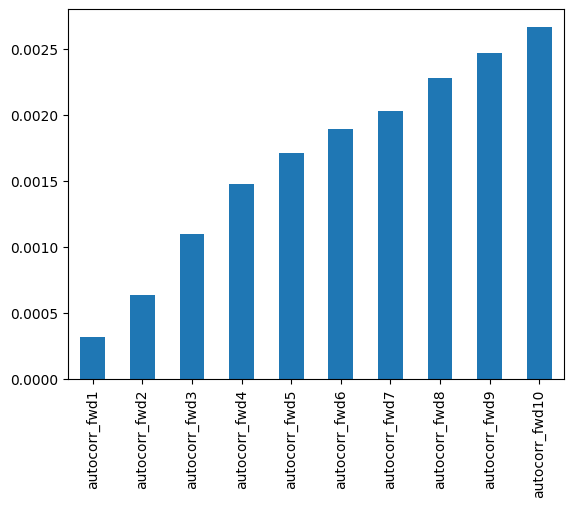

In [179]:
pd.Series({
    'autocorr_fwd1': df['vwap_dev_norm'].corr(df['ret_fwd1']),
    'autocorr_fwd2': df['vwap_dev_norm'].corr(df['ret_fwd2']),
    'autocorr_fwd3': df['vwap_dev_norm'].corr(df['ret_fwd3']),
    'autocorr_fwd4': df['vwap_dev_norm'].corr(df['ret_fwd4']),
    'autocorr_fwd5': df['vwap_dev_norm'].corr(df['ret_fwd5']),
    'autocorr_fwd6': df['vwap_dev_norm'].corr(df['ret_fwd6']),
    'autocorr_fwd7': df['vwap_dev_norm'].corr(df['ret_fwd7']),
    'autocorr_fwd8': df['vwap_dev_norm'].corr(df['ret_fwd8']),
    'autocorr_fwd9': df['vwap_dev_norm'].corr(df['ret_fwd9']),
    'autocorr_fwd10': df['vwap_dev_norm'].corr(df['ret_fwd10']),
}).plot(kind='bar')



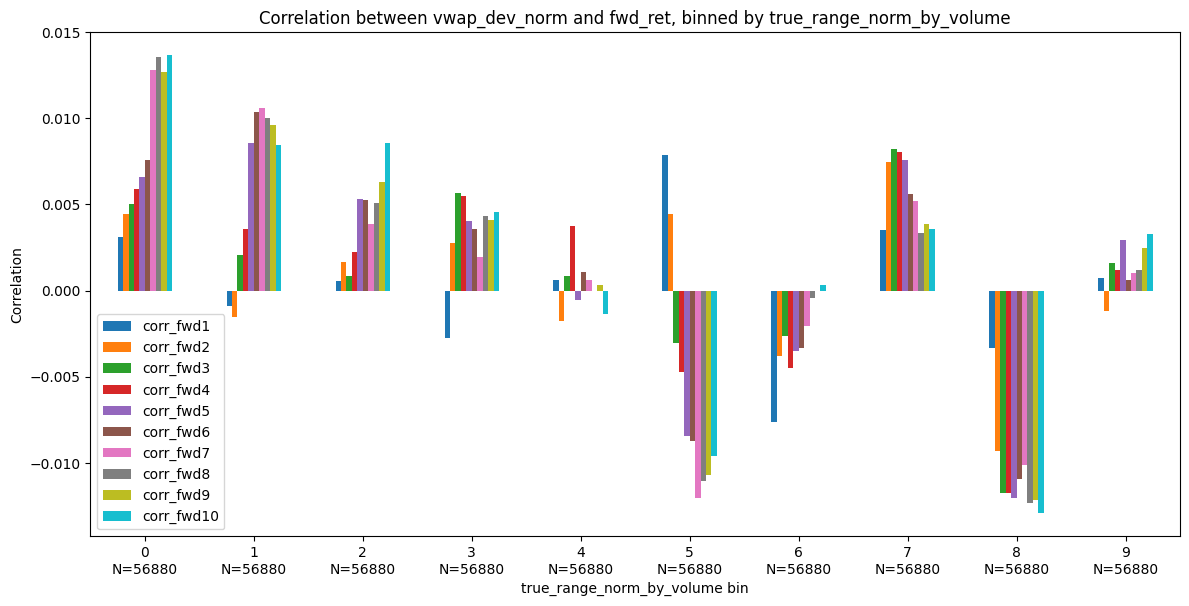

In [180]:
# Calculate the correlation between vwap_dev_norm and each fwd_ret, but within bins of true_range_norm_by_volume

num_bins = 10
# Bin the true_range_norm_by_volume column using quantiles for more even bin sizes
df['trnbv_bin'] = pd.qcut(df['true_range_norm_by_volume_norm'], num_bins, labels=False, duplicates='drop')
#df['trnbv_bin'] = pd.cut(df['true_range_norm_by_volume'], num_bins, labels=False, duplicates='drop')

corrs = []
for bin_id, group in df.groupby('trnbv_bin'):
    entry = {
        'bin': bin_id,
        'corr_fwd1': group['vwap_dev_norm'].corr(group['ret_fwd1']),
        'corr_fwd2': group['vwap_dev_norm'].corr(group['ret_fwd2']),
        'corr_fwd3': group['vwap_dev_norm'].corr(group['ret_fwd3']),
        'corr_fwd4': group['vwap_dev_norm'].corr(group['ret_fwd4']),
        'corr_fwd5': group['vwap_dev_norm'].corr(group['ret_fwd5']),
        'corr_fwd6': group['vwap_dev_norm'].corr(group['ret_fwd6']),
        'corr_fwd7': group['vwap_dev_norm'].corr(group['ret_fwd7']),
        'corr_fwd8': group['vwap_dev_norm'].corr(group['ret_fwd8']),
        'corr_fwd9': group['vwap_dev_norm'].corr(group['ret_fwd9']),
        'corr_fwd10': group['vwap_dev_norm'].corr(group['ret_fwd10']),
    }
    corrs.append(entry)

corrs_df = pd.DataFrame(corrs).set_index('bin')


# Add sample size annotations to each bin in the bar plot

# Get bin counts from the original binning
bin_counts = df['trnbv_bin'].value_counts().sort_index()

# Plot as before
ax = corrs_df.plot(kind='bar', figsize=(12, 6))
plt.ylabel('Correlation')
plt.title('Correlation between vwap_dev_norm and fwd_ret, binned by true_range_norm_by_volume')
plt.xlabel('true_range_norm_by_volume bin')
plt.xticks(rotation=0)
plt.tight_layout()

# Annotate sample sizes on x-axis labels, handling possible float/integer label values robustly
new_labels = []
for label in ax.get_xticklabels():
    label_text = label.get_text()
    try:
        # Attempt to parse as float and then int, for cases like '0.0'
        bin_number = int(float(label_text))
    except (ValueError, TypeError):
        # If cannot parse, leave as is (fallback) with empty count
        bin_number = label_text
    count = bin_counts.get(bin_number, 0)
    new_labels.append(f'{bin_number}\nN={count}')
ax.set_xticklabels(new_labels)

plt.show()

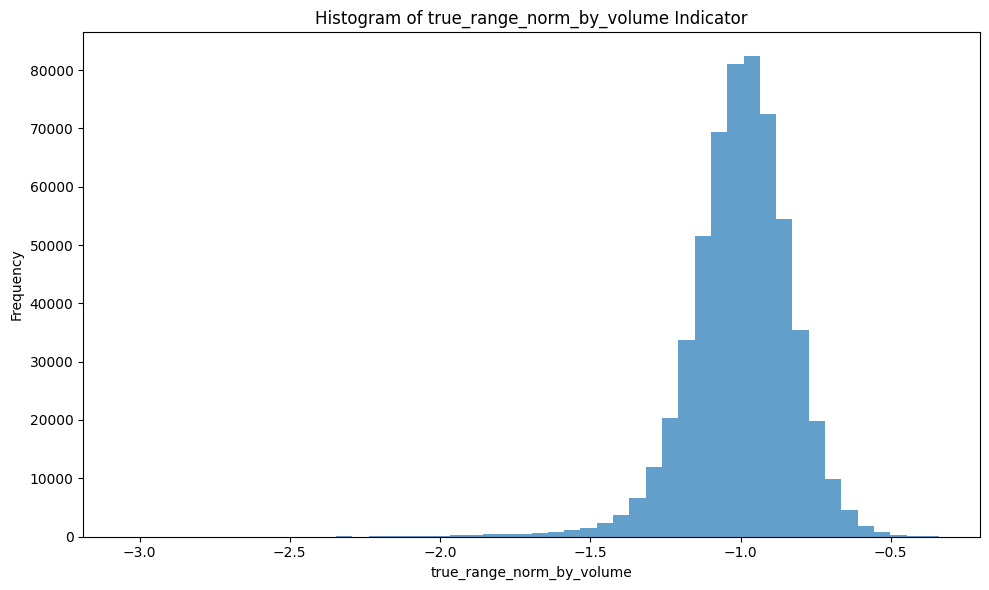

In [181]:
plt.figure(figsize=(10, 6))
plt.hist(df['true_range_norm_by_volume_norm'].dropna(), bins=50, alpha=0.7)
plt.xlabel('true_range_norm_by_volume')
plt.ylabel('Frequency')
plt.title('Histogram of true_range_norm_by_volume Indicator')
plt.tight_layout()
plt.show()

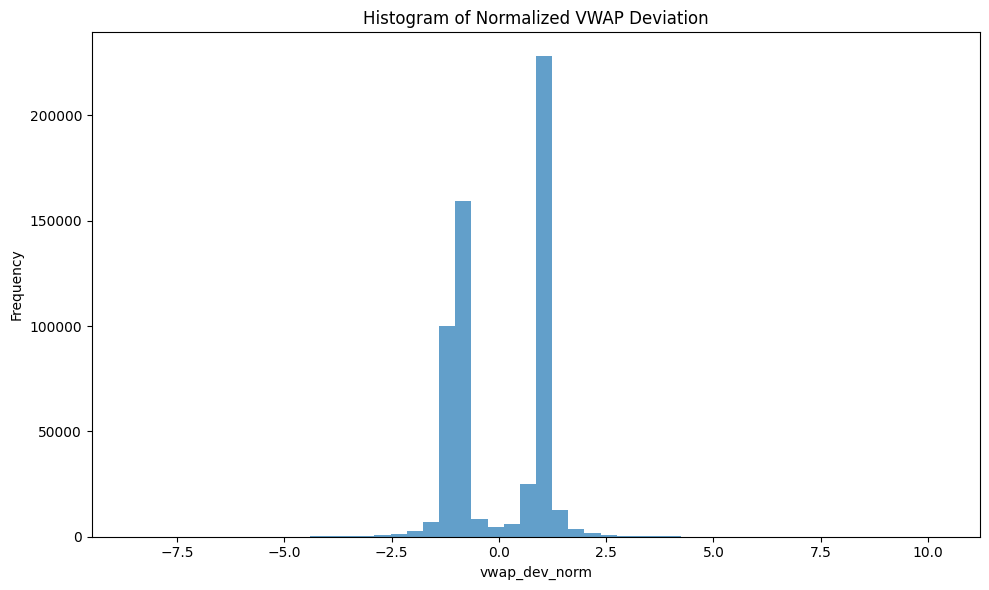

In [182]:
plt.figure(figsize=(10, 6))
plt.hist(df['vwap_dev_norm'].dropna(), bins=50, alpha=0.7)
plt.xlabel('vwap_dev_norm')
plt.ylabel('Frequency')
plt.title('Histogram of Normalized VWAP Deviation')
plt.tight_layout()
plt.show()

In [183]:
# Consolidate backtest dataframe with desired columns and correct column names
backtest_df = df.loc[:, [
    'timestamp',
    'close',
    'vwap_dev_norm',
    'true_range_norm_by_volume_norm',
    'ret_fwd1', 'ret_fwd2', 'ret_fwd3', 'ret_fwd4', 'ret_fwd5',
    'ret_fwd6', 'ret_fwd7', 'ret_fwd8', 'ret_fwd9', 'ret_fwd10'
]].copy().dropna()

# Optional: display a preview for verification
display(backtest_df.head())

,timestamp,close,vwap_dev_norm,true_range_norm_by_volume_norm,ret_fwd1,ret_fwd2,ret_fwd3,ret_fwd4,ret_fwd5,ret_fwd6,ret_fwd7,ret_fwd8,ret_fwd9,ret_fwd10
28,2025-01-06 00:28:00,3645.64,1.033353,-0.853250,-0.001092,-0.001035,-0.001046,0.000222,-0.002224,-0.002923,-0.004299,-0.003459,-0.003735,-0.004142
29,2025-01-06 00:29:00,3641.66,1.002271,-0.720312,0.000058,0.000047,0.001314,-0.001132,-0.001831,-0.003207,-0.002367,-0.002642,-0.003050,-0.001833
30,2025-01-06 00:30:00,3641.87,1.002522,-0.992392,-0.000011,0.001257,-0.001190,-0.001888,-0.003265,-0.002425,-0.002700,-0.003108,-0.001891,-0.002276
31,2025-01-06 00:31:00,3641.83,1.001256,-0.941971,0.001268,-0.001179,-0.001877,-0.003254,-0.002414,-0.002689,-0.003097,-0.001880,-0.002265,-0.002615
32,2025-01-06 00:32:00,3646.45,1.033625,-0.940923,-0.002446,-0.003145,-0.004521,-0.003682,-0.003957,-0.004364,-0.003148,-0.003533,-0.003883,-0.003971


In [184]:
import numpy as np

# Adjust the take profit threshold
tp = 0.005   # 30bps = 0.30%
sl = -0.005  # -10bps = -0.10%

# Columns for forward returns (already present in backtest_df)
ret_cols = [f'ret_fwd{i}' for i in range(1, 11)]

def check_tp_sl(row):
    rets = row[ret_cols].values
    tp_hit = np.where(rets >= tp)[0]
    sl_hit = np.where(rets <= sl)[0]
    
    # Find which comes first
    first_tp = tp_hit[0] if len(tp_hit) > 0 else np.inf
    first_sl = sl_hit[0] if len(sl_hit) > 0 else np.inf

    if first_tp < first_sl:
        # TP hit first
        return 'TP', rets[first_tp]
    elif first_sl < first_tp:
        # SL hit first
        return 'SL', rets[first_sl]
    else:
        # Neither hit: take final available return
        return 'NONE', rets[-1]

# Apply function row-wise to determine outcome and PnL
tp_sl_res = backtest_df.apply(lambda row: check_tp_sl(row), axis=1)
backtest_df['tp_sl'] = tp_sl_res.apply(lambda x: x[0])
backtest_df['pnl'] = tp_sl_res.apply(lambda x: x[1])

# Optional: display new columns for verification
display(backtest_df[['timestamp', 'tp_sl', 'pnl']].head())

,timestamp,tp_sl,pnl
28,2025-01-06 00:28:00,NONE,-0.004142
29,2025-01-06 00:29:00,NONE,-0.001833
30,2025-01-06 00:30:00,NONE,-0.002276
31,2025-01-06 00:31:00,NONE,-0.002615
32,2025-01-06 00:32:00,NONE,-0.003971


In [185]:
# Entry rule columns:

# 1. vwap_dev_norm entry signals: > 1.5 -> short; < -1.5 -> long
backtest_df['entry_vwap_dev'] = np.where(
    backtest_df['vwap_dev_norm'] > 2, 'short',
    np.where(backtest_df['vwap_dev_norm'] < -2, 'long', 'none')
)

# 2. true_range_norm_by_volume_norm filters (reversion/trend regime):
#    > -1: revert; <= -1: trend
backtest_df['entry_tr_volregime'] = np.where(
    backtest_df['true_range_norm_by_volume_norm'] > -1, 'revert', 'trend'
)

# Optional: show
display(backtest_df[['timestamp', 'entry_vwap_dev', 'entry_tr_volregime']].head())

,timestamp,entry_vwap_dev,entry_tr_volregime
28,2025-01-06 00:28:00,none,revert
29,2025-01-06 00:29:00,none,revert
30,2025-01-06 00:30:00,none,revert
31,2025-01-06 00:31:00,none,revert
32,2025-01-06 00:32:00,none,revert


In [196]:
# Given tp=30bps (0.003), sl=10bps (0.001), recompute TRUE tp/sl logic based on *true* trade direction (entry_vwap_dev)

tp_true = 0.003   # 30 bps
sl_true = -0.001  # -10 bps

# Find all ret_fwd columns
ret_fwd_cols = [col for col in backtest_df.columns if col.startswith('ret_fwd')]

def tpsl_true_row(row):
    entry = row['entry_vwap_dev']
    if entry == 'long':
        # Use forward returns as-is
        fwd_rets = row[ret_fwd_cols].values
        tp_hit = np.where(fwd_rets >= tp_true)[0]
        sl_hit = np.where(fwd_rets <= sl_true)[0]
        first_tp = tp_hit[0] if len(tp_hit) > 0 else np.inf
        first_sl = sl_hit[0] if len(sl_hit) > 0 else np.inf
        if first_tp < first_sl:
            return 'TP', fwd_rets[first_tp]
        elif first_sl < first_tp:
            return 'SL', fwd_rets[first_sl]
        else:
            return 'NONE', fwd_rets[-1]
    elif entry == 'short':
        # For shorts, invert the returns (profit if price falls)
        fwd_rets = -row[ret_fwd_cols].values
        tp_hit = np.where(fwd_rets >= tp_true)[0]   # price moved down 30bps
        sl_hit = np.where(fwd_rets <= sl_true)[0]   # price moved up 10bps
        first_tp = tp_hit[0] if len(tp_hit) > 0 else np.inf
        first_sl = sl_hit[0] if len(sl_hit) > 0 else np.inf
        if first_tp < first_sl:
            return 'TP', -row[ret_fwd_cols].values[first_tp]
        elif first_sl < first_tp:
            return 'SL', -row[ret_fwd_cols].values[first_sl]
        else:
            # No TP/SL hit; final return as PnL (sign adjusted)
            return 'NONE', -row[ret_fwd_cols].values[-1]
    else:
        # entry == 'none': no trade
        return 'NONE', 0.0

true_res = backtest_df.apply(tpsl_true_row, axis=1)
backtest_df['true_stop'] = true_res.apply(lambda x: x[0])
backtest_df['true_pnl'] = true_res.apply(lambda x: x[1])
backtest_df['true_position'] = backtest_df['entry_vwap_dev']

backtest_df.head()

,timestamp,close,vwap_dev_norm,true_range_norm_by_volume_norm,ret_fwd1,ret_fwd2,ret_fwd3,ret_fwd4,ret_fwd5,ret_fwd6,...,pnl,entry_vwap_dev,entry_tr_volregime,true_position,true_stop,true_pnl,adj_true_position,adj_true_stop,adj_true_pnl,true_range_bin
28,2025-01-06 00:28:00,3645.64,1.033353,-0.853250,-0.001092,-0.001035,-0.001046,0.000222,-0.002224,-0.002923,...,-0.004142,none,revert,none,NONE,0.0,none,NONE,-0.004142,vhigh_vol
29,2025-01-06 00:29:00,3641.66,1.002271,-0.720312,0.000058,0.000047,0.001314,-0.001132,-0.001831,-0.003207,...,-0.001833,none,revert,none,NONE,0.0,none,NONE,-0.001833,vhigh_vol
30,2025-01-06 00:30:00,3641.87,1.002522,-0.992392,-0.000011,0.001257,-0.001190,-0.001888,-0.003265,-0.002425,...,-0.002276,none,revert,none,NONE,0.0,none,NONE,-0.002276,mid_vol
31,2025-01-06 00:31:00,3641.83,1.001256,-0.941971,0.001268,-0.001179,-0.001877,-0.003254,-0.002414,-0.002689,...,-0.002615,none,revert,none,NONE,0.0,none,NONE,-0.002615,high_vol
32,2025-01-06 00:32:00,3646.45,1.033625,-0.940923,-0.002446,-0.003145,-0.004521,-0.003682,-0.003957,-0.004364,...,-0.003971,none,revert,none,NONE,0.0,none,NONE,-0.003971,high_vol


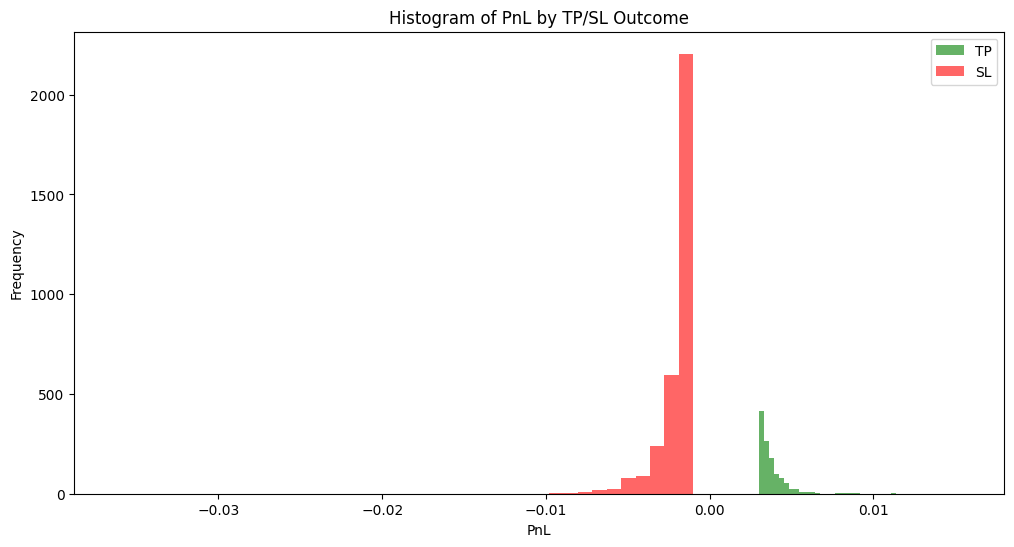

In [199]:
import matplotlib.pyplot as plt

# Plot histogram of PnL for only TP and SL outcomes
plt.figure(figsize=(12, 6))
outcomes = ['TP', 'SL']
colors = {'TP': 'green', 'SL': 'red'}

for outcome in outcomes:
    pnl_data = backtest_df.loc[backtest_df['true_stop'] == outcome, 'true_pnl']
    plt.hist(pnl_data, bins=40, alpha=0.6, label=outcome, color=colors[outcome])

plt.title("Histogram of PnL by TP/SL Outcome")
plt.xlabel("PnL")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [187]:
# Show dataframe without the ret_fwd columns
cols_to_exclude = [col for col in backtest_df.columns if col.startswith('ret_fwd')]
df_without_ret_fwd = backtest_df.drop(columns=cols_to_exclude)
display(df_without_ret_fwd.head())

,timestamp,close,vwap_dev_norm,true_range_norm_by_volume_norm,tp_sl,pnl,entry_vwap_dev,entry_tr_volregime,true_position,true_stop,true_pnl
28,2025-01-06 00:28:00,3645.64,1.033353,-0.853250,NONE,-0.004142,none,revert,none,NONE,-0.004142
29,2025-01-06 00:29:00,3641.66,1.002271,-0.720312,NONE,-0.001833,none,revert,none,NONE,-0.001833
30,2025-01-06 00:30:00,3641.87,1.002522,-0.992392,NONE,-0.002276,none,revert,none,NONE,-0.002276
31,2025-01-06 00:31:00,3641.83,1.001256,-0.941971,NONE,-0.002615,none,revert,none,NONE,-0.002615
32,2025-01-06 00:32:00,3646.45,1.033625,-0.940923,NONE,-0.003971,none,revert,none,NONE,-0.003971


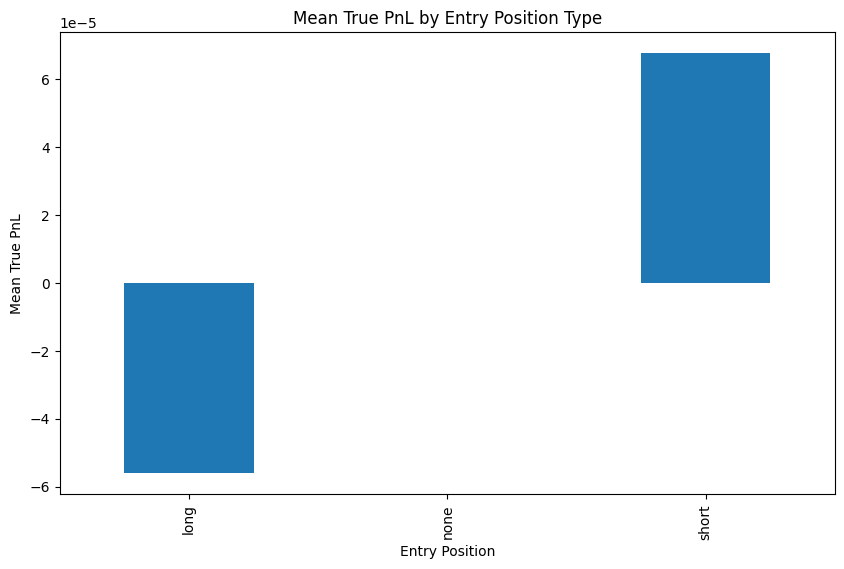

In [200]:
import matplotlib.pyplot as plt

# Group by position type ('short', 'long', 'none') and plot the mean of true_pnl
mean_true_pnl = backtest_df.groupby('entry_vwap_dev')['true_pnl'].mean()

plt.figure(figsize=(10, 6))
mean_true_pnl.plot(kind='bar')
plt.title('Mean True PnL by Entry Position Type')
plt.xlabel('Entry Position')
plt.ylabel('Mean True PnL')
plt.show()

In [203]:
# Bin true_range readings into 5 quantiles (very low, low, medium, high, very high volatility)
true_range_bins = pd.qcut(
    backtest_df['true_range_norm_by_volume_norm'],
    q=10,
)
backtest_df['true_range_bin'] = true_range_bins

backtest_df.head()

,timestamp,close,vwap_dev_norm,true_range_norm_by_volume_norm,ret_fwd1,ret_fwd2,ret_fwd3,ret_fwd4,ret_fwd5,ret_fwd6,...,pnl,entry_vwap_dev,entry_tr_volregime,true_position,true_stop,true_pnl,adj_true_position,adj_true_stop,adj_true_pnl,true_range_bin
28,2025-01-06 00:28:00,3645.64,1.033353,-0.853250,-0.001092,-0.001035,-0.001046,0.000222,-0.002224,-0.002923,...,-0.004142,none,revert,none,NONE,0.0,none,NONE,-0.004142,"(-0.87, -0.807]"
29,2025-01-06 00:29:00,3641.66,1.002271,-0.720312,0.000058,0.000047,0.001314,-0.001132,-0.001831,-0.003207,...,-0.001833,none,revert,none,NONE,0.0,none,NONE,-0.001833,"(-0.807, -0.339]"
30,2025-01-06 00:30:00,3641.87,1.002522,-0.992392,-0.000011,0.001257,-0.001190,-0.001888,-0.003265,-0.002425,...,-0.002276,none,revert,none,NONE,0.0,none,NONE,-0.002276,"(-1.029, -0.992]"
31,2025-01-06 00:31:00,3641.83,1.001256,-0.941971,0.001268,-0.001179,-0.001877,-0.003254,-0.002414,-0.002689,...,-0.002615,none,revert,none,NONE,0.0,none,NONE,-0.002615,"(-0.955, -0.915]"
32,2025-01-06 00:32:00,3646.45,1.033625,-0.940923,-0.002446,-0.003145,-0.004521,-0.003682,-0.003957,-0.004364,...,-0.003971,none,revert,none,NONE,0.0,none,NONE,-0.003971,"(-0.955, -0.915]"


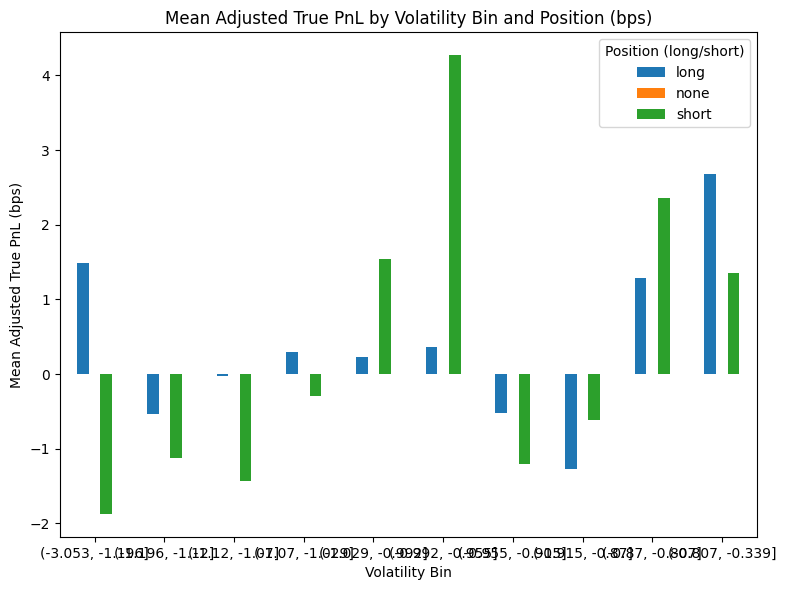

In [204]:
# Group by true_range_bin (volatility level) and adj_true_position (long/short), calculate mean adjusted pnl in bps
grouped = backtest_df.groupby(['true_range_bin', 'adj_true_position'])['true_pnl'].mean().unstack()

# Convert mean PnL to basis points (bps)
grouped_bps = grouped * 10000

# Plot the grouped mean in bps
ax = grouped_bps.plot(kind='bar', figsize=(8,6))
plt.title("Mean Adjusted True PnL by Volatility Bin and Position (bps)")
plt.ylabel("Mean Adjusted True PnL (bps)")
plt.xlabel("Volatility Bin")
plt.xticks(rotation=0)
plt.legend(title="Position (long/short)")
plt.tight_layout()
plt.show()

<Axes: xlabel='time'>

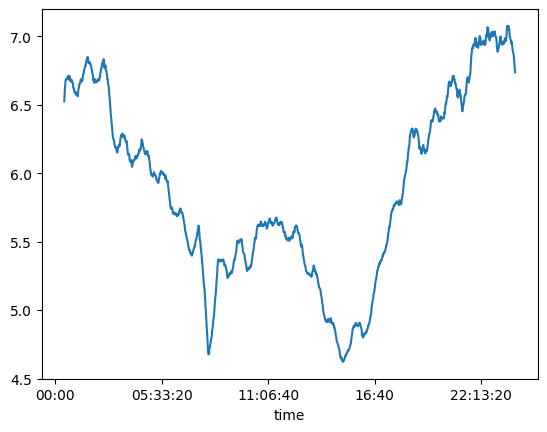

In [52]:
s1 = df.groupby('time')['true_range_norm_by_volume'].sum()#.plot()

s1.rolling(window=30).mean().plot()

<Axes: xlabel='time'>

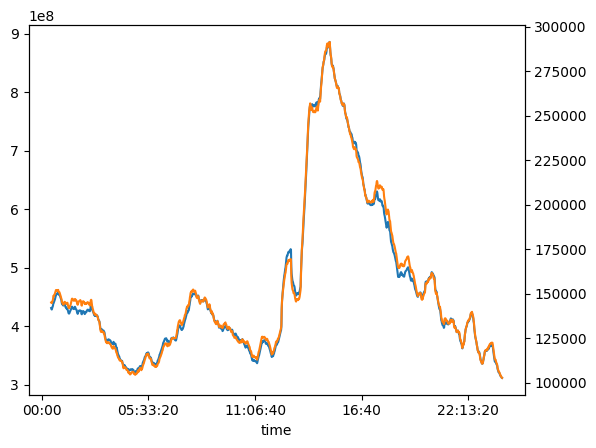

In [50]:
s1 = df.groupby('time')['dollar_volume'].sum()#.plot()
s2 = df.groupby('time')['true_range'].sum()#.plot(secondary_y=True)
s3 = df.groupby('time')['volume'].sum()

s1.rolling(window=30).mean().plot()
#s2.rolling(window=30).mean().plot(secondary_y=True)
s3.rolling(window=30).mean().plot(secondary_y=True)

<Axes: >

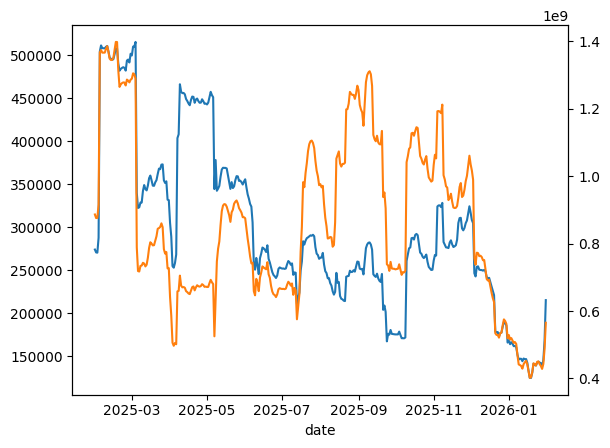

In [26]:

s1.rolling(window=30).std().plot()
s2.rolling(window=30).std().plot(secondary_y=True)

In [24]:
from statsmodels.tsa.stattools import adfuller, kpss

def adf_test(x):
    res = adfuller(x.dropna())
    return {"stat": res[0], "p": res[1]}

def kpss_test(x):
    res = kpss(x.dropna(), regression="c", nlags="auto")
    return {"stat": res[0], "p": res[1]}

s1_adf = adf_test(df["s1"])
s2_adf = adf_test(df["s2"])
s1_kpss = kpss_test(df["s1"])
s2_kpss = kpss_test(df["s2"])

print("s1 ADF:", s1_adf, "s2 ADF:", s2_adf)
print("s1 KPSS:", s1_kpss, "s2 KPSS:", s2_kpss)

KeyError: 's1'

<Axes: title={'center': 'dollar_volume'}, xlabel='date'>

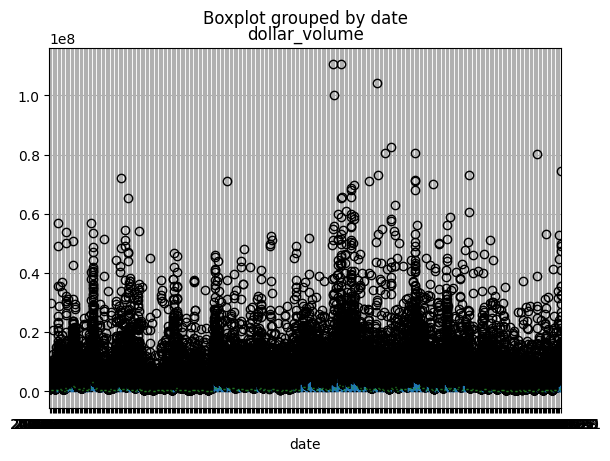

In [ ]:
df.boxplot(column='dollar_volume', by='date')
#why so many dots here?